In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter("ignore")

In [ ]:
# Step 1: Read the ratings data from the CSV file
df = pd.read_csv('filtered_df.csv')

# Step 2: Remove duplicate user-title pairs, keeping only the first occurrence of each
# This ensures that if a user rated the same movie multiple times, only the first rating is kept.
df = df.drop_duplicates(subset=['user', 'Title'], keep='first')

# Step 3: Count how many ratings each title has
title_counts = df['Title'].value_counts()

# Step 4: Filter titles that have at least 1% of total users providing ratings
# Given a dataset with 1000 unique users, this translates to titles with more than 30 ratings.
min_ratings_threshold = 0.03 * 1000
popular_titles = title_counts[title_counts > min_ratings_threshold].index

# Step 5: Filter the DataFrame to retain only movies with sufficient ratings
df = df[df['Title'].isin(popular_titles)]

# Step 6: Display the counts of remaining titles
final_title_counts = df['Title'].value_counts()

# Output the result
print(final_title_counts)

Title
Get Out            819
Parasite           811
Knives Out         802
Barbie             801
Dune               792
                  ... 
Dragonfly           31
CB4                 31
Sidekicks           31
Desire              31
So Long, My Son     31
Name: count, Length: 12594, dtype: int64


In [6]:
# Step 1: Read movie metadata from the CSV file
movies = pd.read_csv('found_metadata.csv')

# Step 2: Select only the necessary columns
selected_columns = ['Title', 'Year', 'Rated', 'Released', 'Runtime', 'Genre', 
                    'Director', 'Writer', 'Actors', 'Plot', 'Language', 'Country']
movies = movies[selected_columns]

# Step 3: Define a reusable function to split and clean string lists (handling NaN values)
def split_and_strip(column_value):
    # Check if the value is a string; otherwise, return an empty list
    if isinstance(column_value, str):
        return [item.strip() for item in column_value.split(',')]
    return []

# Step 4: Apply the reusable function to the relevant columns
columns_to_split = ['Genre', 'Director', 'Writer', 'Actors', 'Language', 'Country']
for column in columns_to_split:
    movies[f'{column} List'] = movies[column].apply(split_and_strip)

# Step 5: Select the relevant columns for the final DataFrame
final_columns = ['Title', 'Year', 'Rated', 'Runtime', 'Genre List', 'Director List', 
                 'Writer List', 'Actors List', 'Plot', 'Language List', 'Country List']
movies = movies[final_columns]

# Step 6: Display the first few rows of the final DataFrame
movies.head(3)

,Title,Year,Rated,Runtime,Genre List,Director List,Writer List,Actors List,Plot,Language List,Country List
0,A Fantastic Woman,2017,R,104 min,[Drama],[Sebastián Lelio],"[Sebastián Lelio, Gonzalo Maza, Eliseo Altunaga]","[Daniela Vega, Francisco Reyes, Luis Gnecco]","Marina, a transgender woman who works as a wai...","[Spanish, Chinese]","[Chile, Spain, Germany, United States]"
1,The Fabulous Baker Boys,1989,R,114 min,"[Comedy, Drama, Music]",[Steve Kloves],[Steve Kloves],"[Jeff Bridges, Michelle Pfeiffer, Beau Bridges]","The lives of two struggling musicians, who hap...",[English],"[United States, West Germany]"
2,The Call,2013,R,94 min,"[Drama, Thriller]",[Brad Anderson],"[Richard D'Ovidio, Nicole D'Ovidio, Jon Bokenk...","[Halle Berry, Evie Thompson, Abigail Breslin]",When a veteran 911 operator takes a life-alter...,[English],[United States]


In [6]:
movies.to_csv('movies_cleaned.csv')

In [7]:
# Step 1: Compute mean and standard deviation of ratings for each user
# This helps normalize user-specific rating tendencies (harsh or generous raters)
user_stats = df.groupby('user')['Rating'].agg(['mean', 'std']).reset_index()
user_stats.columns = ['user', 'User Mean', 'User Std']

# Step 2: Merge the user-specific statistics with the original DataFrame
# Allows us to calculate z-scores for each user's ratings
df = df.merge(user_stats, on='user')

# Step 3: Calculate the z-score of each rating
# This standardizes the ratings by adjusting for the user's mean and variability
df['Z-score Rating'] = (df['Rating'] - df['User Mean']) / df['User Std']

# Step 4: Compute the number of ratings for each movie
# Helps in weighting the average z-score by popularity
movie_counts = df.groupby('Title')['Rating'].count().reset_index()
movie_counts.columns = ['Title', 'Num Ratings']

# Step 5: Compute the weighted average z-score for each movie
# We weight the z-score by the number of ratings each movie has
average_z_scores = (
    df.groupby('Title')
    .apply(lambda x: (x['Z-score Rating'] * len(x)).sum() / len(x))
    .reset_index(name='Weighted Average Z-score')
)

# Step 6: Merge with the number of ratings and sort by weighted z-score
result = average_z_scores.merge(movie_counts, on='Title').sort_values(by='Weighted Average Z-score', ascending=False)

# Display the top-rated movies based on weighted z-scores
print("\nTop Movies by Weighted Average Z-score:")
print(result)


Top Movies by Weighted Average Z-score:
                                   Title  Weighted Average Z-score  \
6963                            Parasite               1021.286799   
8487   Spider-Man: Into the Spider-Verse                803.983621   
514                                Alien                791.087073   
5751                  Mad Max: Fury Road                774.947086   
12240                           Whiplash                759.999901   
...                                  ...                       ...   
6223                             Morbius               -670.445112   
5064                      Justice League               -675.026096   
5758                          Madame Web               -688.877789   
3273                      Fantastic Four               -717.090904   
8728                       Suicide Squad               -871.198577   

       Num Ratings  
6963           811  
8487           757  
514            706  
5751           702  
12240        

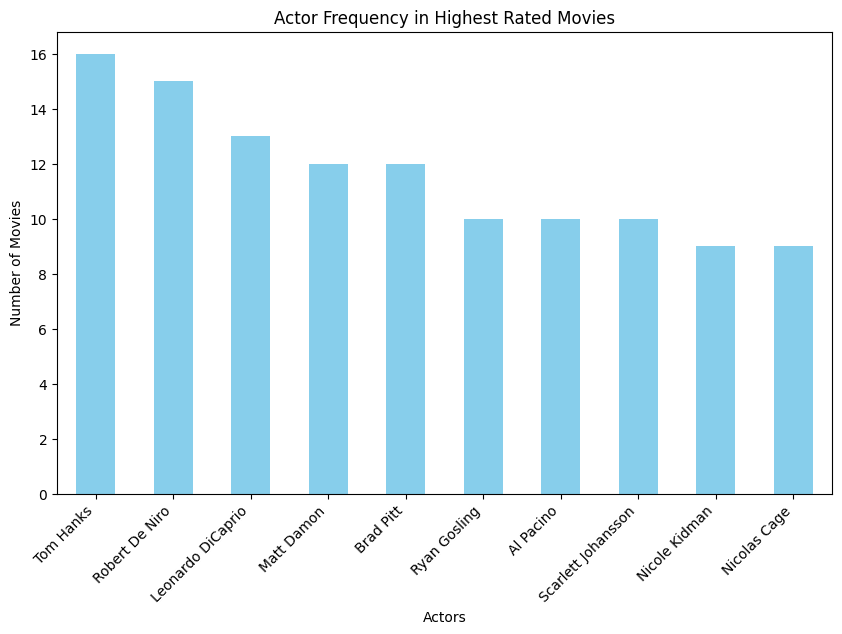

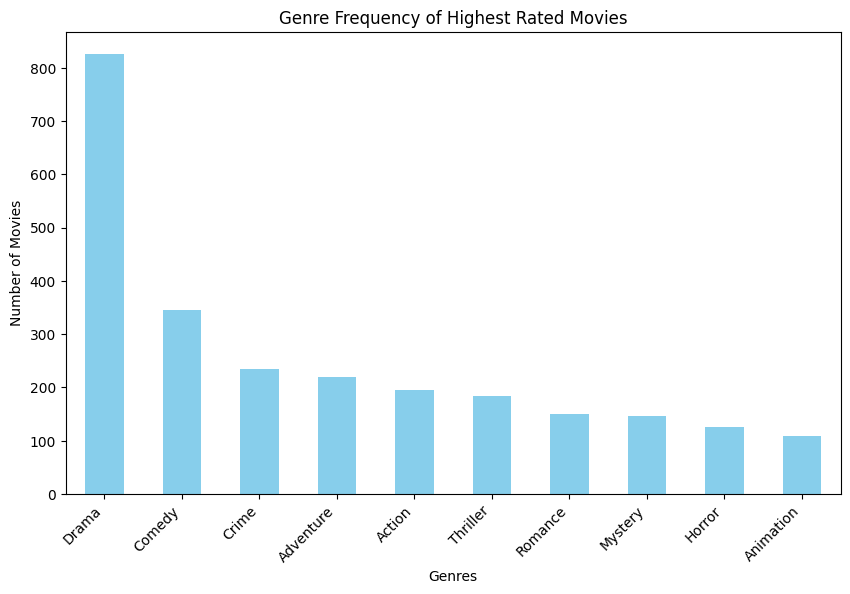

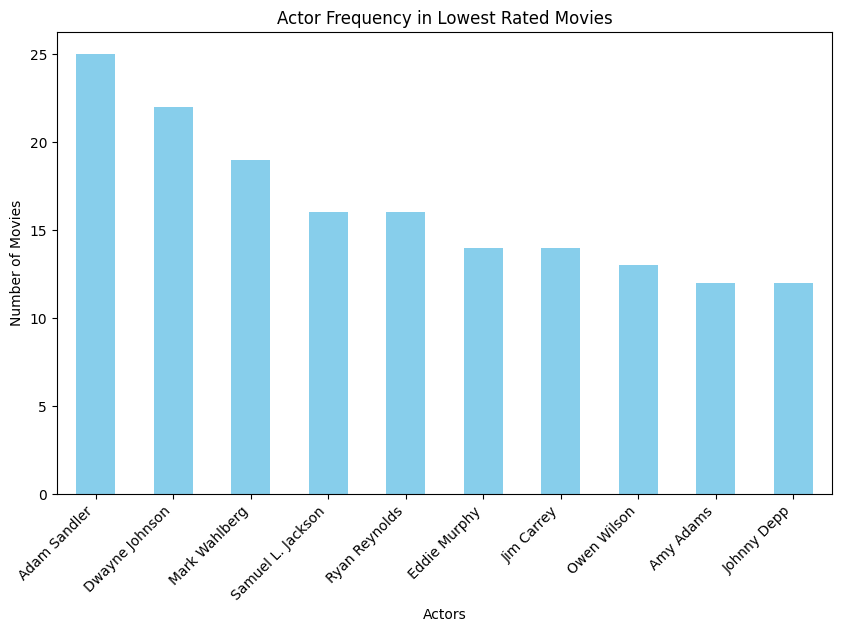

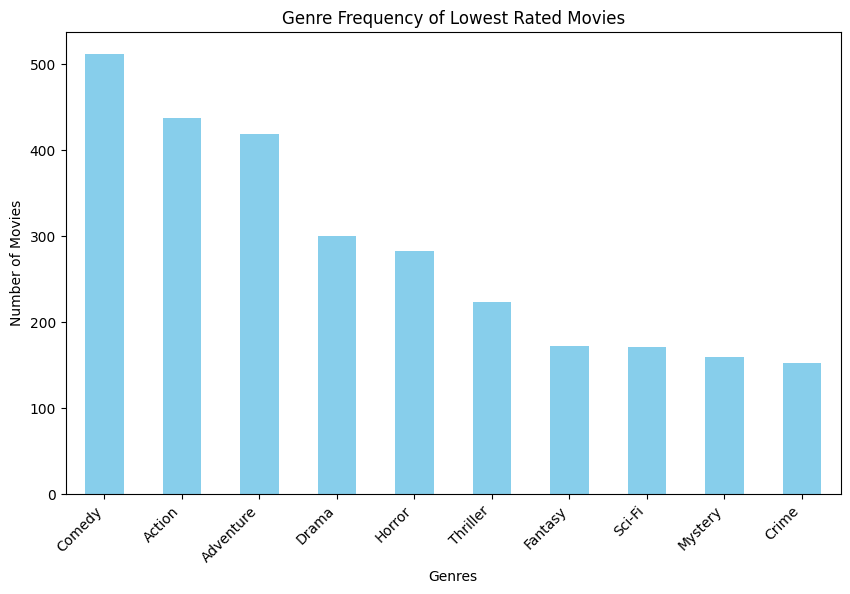

In [8]:
# Step 1: Get the top 10% and bottom 10% movies by weighted average z-score
top10percent = result.iloc[0:int(0.1 * len(result))]
bottom10percent = result.iloc[(len(result) - int(0.1 * len(result))):]

# Step 2: Select corresponding movies from the movies DataFrame
top_movies = movies[movies['Title'].isin(top10percent['Title'])]
bottom_movies = movies[movies['Title'].isin(bottom10percent['Title'])]

# Step 3: Define a reusable function to explode lists, count occurrences, and plot bar charts
def plot_top_counts(df, list_column, chart_title, xlabel, ylabel, color='skyblue', top_n=10):
    # Explode the list column into individual rows
    exploded = df.explode(list_column)
    
    # Count occurrences of each item
    counts = exploded[list_column].value_counts()
    
    # Plot the top N items
    plt.figure(figsize=(10, 6))
    counts.head(top_n).plot(kind='bar', color=color)
    plt.title(chart_title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha='right')
    plt.show()

# Step 4: Plot top actors and genres for the top 10% rated movies
plot_top_counts(
    top_movies, 'Actors List', 'Actor Frequency in Highest Rated Movies', 
    xlabel='Actors', ylabel='Number of Movies'
)

plot_top_counts(
    top_movies, 'Genre List', 'Genre Frequency of Highest Rated Movies', 
    xlabel='Genres', ylabel='Number of Movies'
)

# Step 5: Plot top actors and genres for the bottom 10% rated movies
plot_top_counts(
    bottom_movies, 'Actors List', 'Actor Frequency in Lowest Rated Movies', 
    xlabel='Actors', ylabel='Number of Movies'
)

plot_top_counts(
    bottom_movies, 'Genre List', 'Genre Frequency of Lowest Rated Movies', 
    xlabel='Genres', ylabel='Number of Movies'
)